### Checking the data

[Source](https://data.cityofchicago.org/Buildings/Building-Footprints-Map/hz9b-7nh8)

In [1]:
import geopandas as gpd
from plotnine import *
import numpy as np

In [2]:
df = gpd.read_file("data/chi_bldg_footprints.geojson")

In [4]:
df.dtypes

:id                         object
:version                    object
:created_at    datetime64[ms, UTC]
:updated_at    datetime64[ms, UTC]
bldg_id                     object
cdb_city_i                  object
bldg_statu                  object
f_add1                      object
t_add1                      object
pre_dir1                    object
st_name1                    object
st_type1                    object
unit_name                   object
non_standa                  object
bldg_name1                  object
bldg_name2                  object
comments                    object
stories                     object
orig_bldg_                  object
footprint_                  object
create_use                  object
bldg_creat     datetime64[ms, UTC]
bldg_activ     datetime64[ms, UTC]
bldg_end_d     datetime64[ms, UTC]
demolished     datetime64[ms, UTC]
edit_date      datetime64[ms, UTC]
edit_useri                  object
edit_sourc                  object
qc_date        datet

In [5]:
df['num_stories'] = df['stories'].astype('int32')

In [6]:
df.shape

(820606, 48)

In [7]:
df[df['num_stories']==0].shape

(392608, 48)

In [8]:
df['num_stories'].value_counts()

num_stories
0      392608
2      198439
1      191840
3       33220
4        2072
        ...  
74          1
69          1
110         1
65          1
56          1
Name: count, Length: 70, dtype: int64

^^^ There are about 400,000 buildings in the dataset that have "0" for the "STORIES" value

In [9]:
df[df['no_stories']==0].shape

(0, 48)

In [10]:
df['no_stories'].value_counts()

no_stories
0    820265
1       337
4         2
2         2
Name: count, dtype: int64

^^^ I think I can ignore the `NO_STORIES` variable because it covers only about 0.04% of the dataset

In [11]:
df['num_stories'].value_counts()

num_stories
0      392608
2      198439
1      191840
3       33220
4        2072
        ...  
74          1
69          1
110         1
65          1
56          1
Name: count, Length: 70, dtype: int64

In [12]:
df['stories_count'] = np.where(df['num_stories']==0, 0, 1)

In [13]:
df['stories_count'].value_counts()

stories_count
1    427998
0    392608
Name: count, dtype: int64

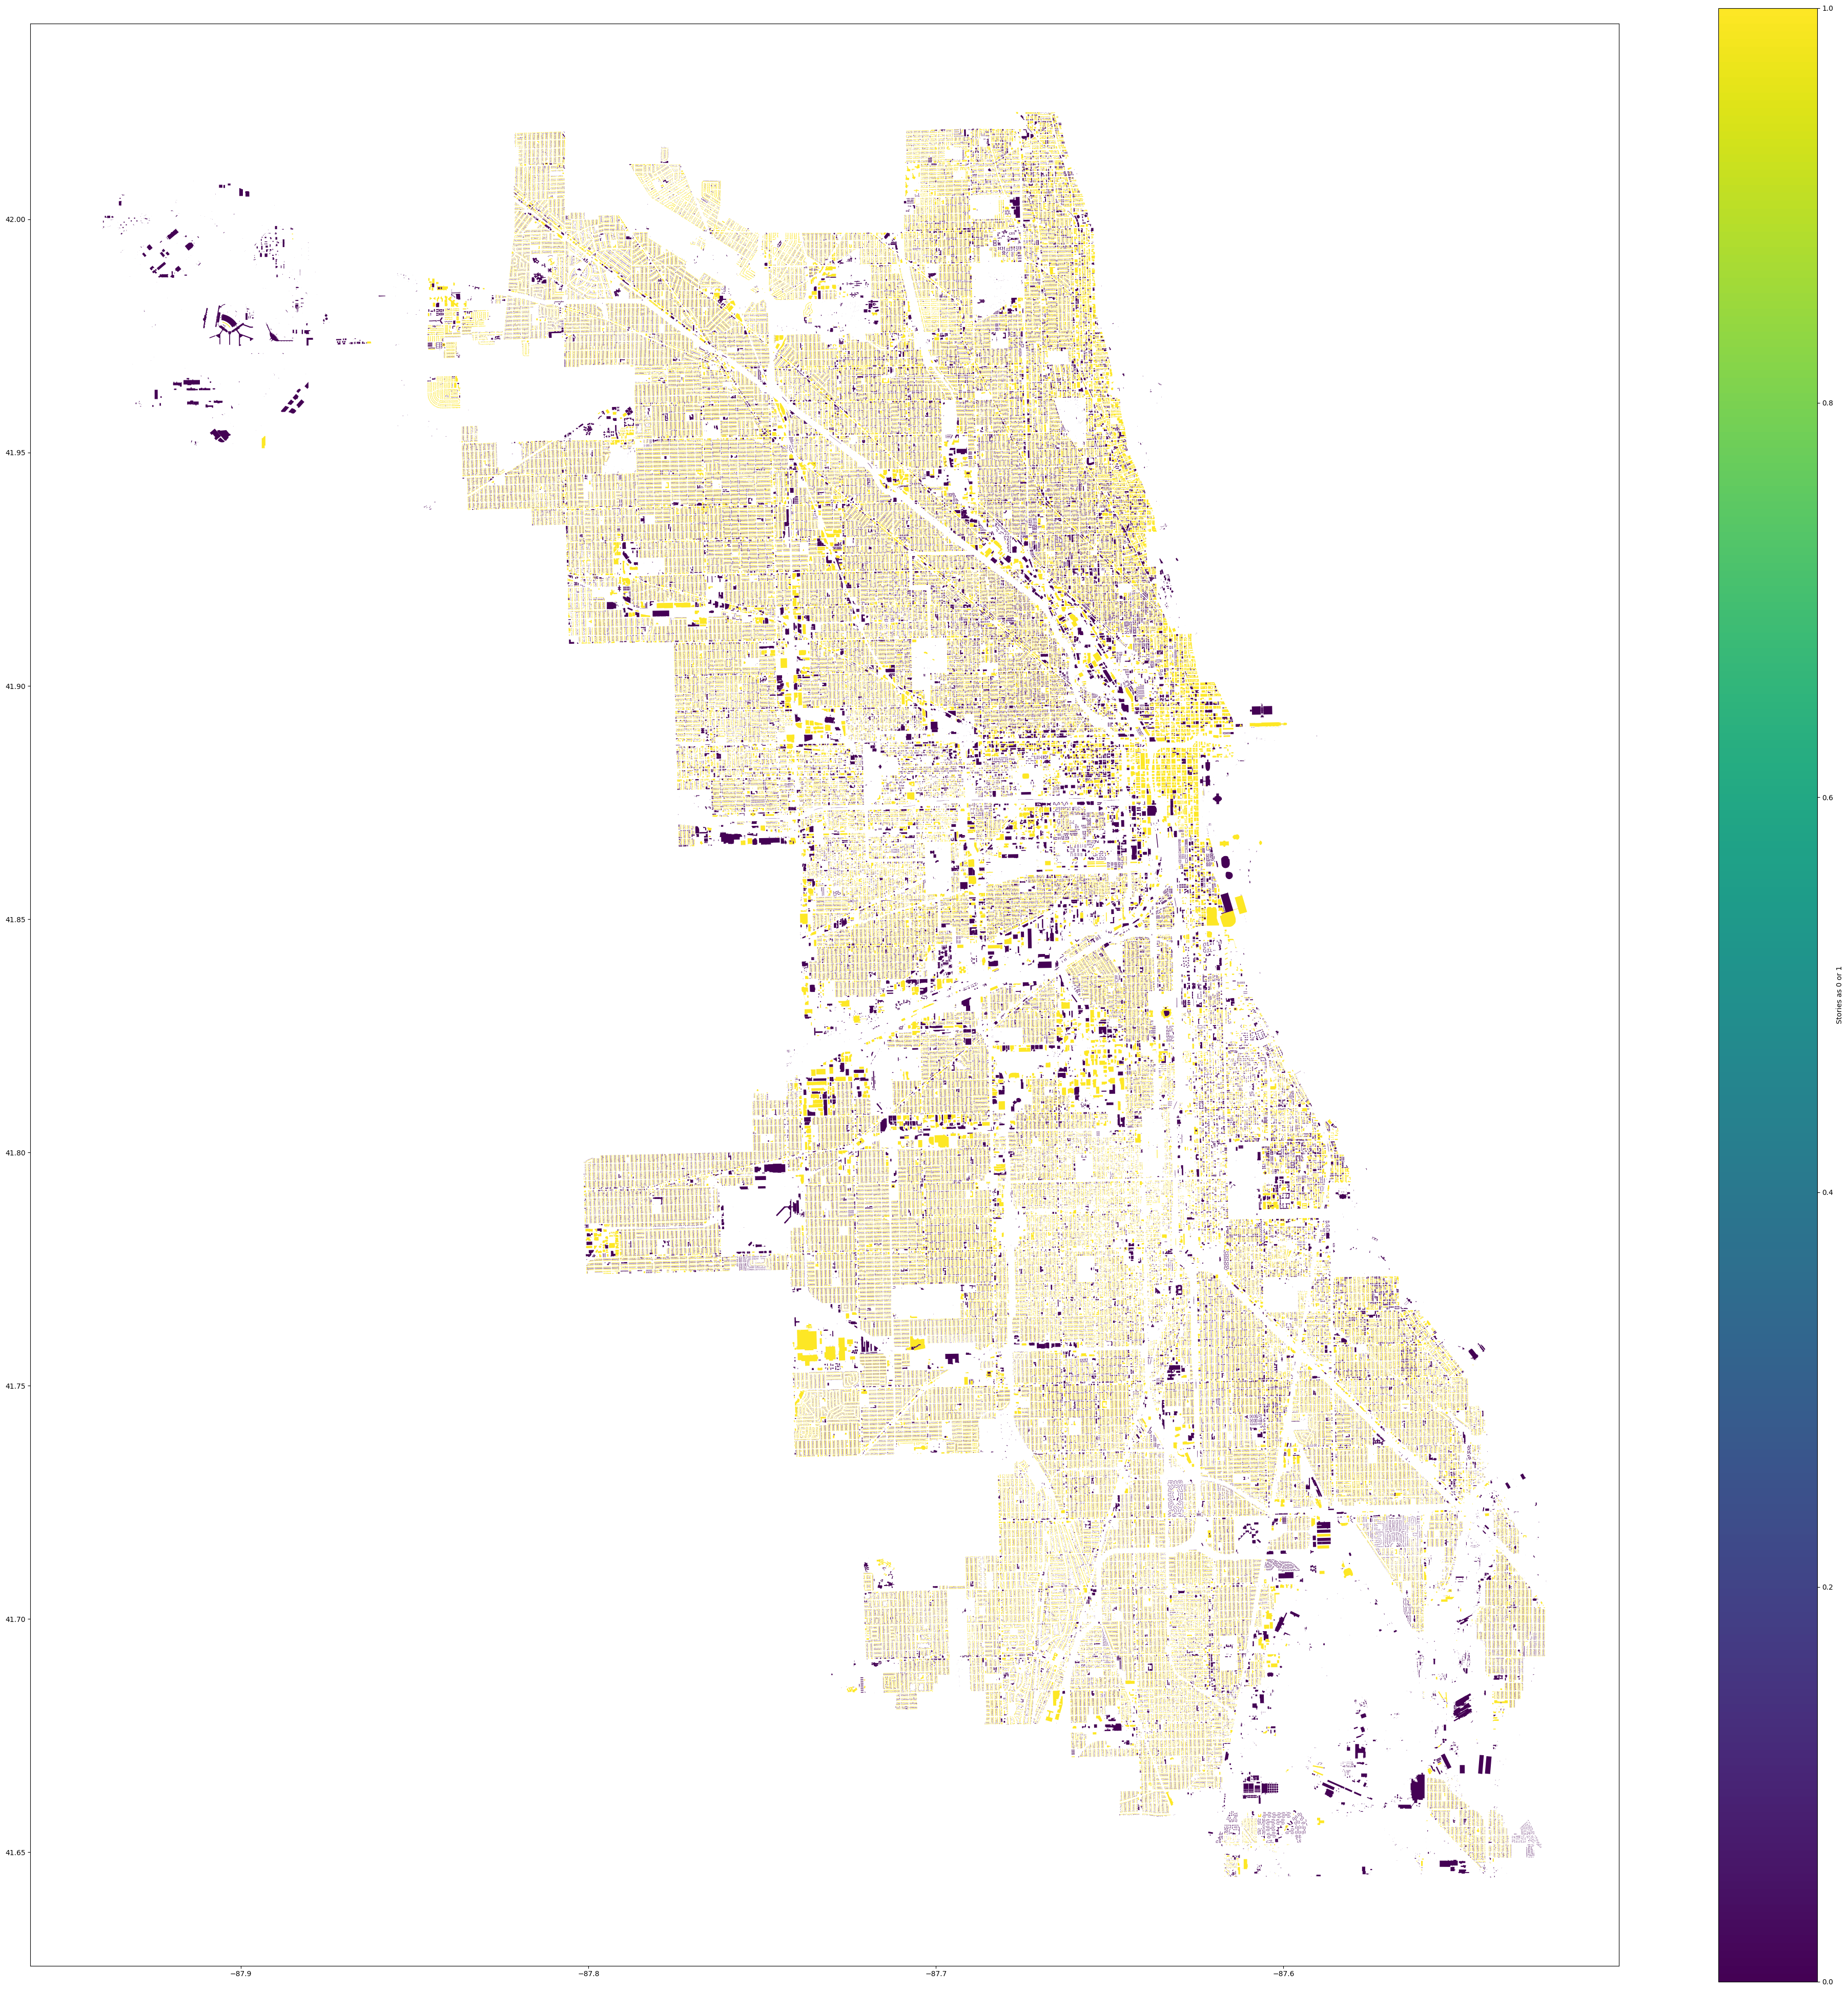

In [14]:
import matplotlib.pyplot as plt



# 2. Plot dynamically based on a variable (e.g., 'population')
fig, ax = plt.subplots(1, 1, figsize=(50, 50))
df.plot(
    column='stories_count', 
    ax=ax, 
    legend=True, 
    cmap='viridis', 
    legend_kwds={'label': 'Stories as 0 or 1'}
)

plt.show()

In [15]:
df['bldg_statu'].value_counts()

bldg_statu
ACTIVE        820456
PROPOSED         140
                   9
DEMOLISHED         1
Name: count, dtype: int64

In [4]:
df[~(df['geometry'].isna())]

,:id,:version,:created_at,:updated_at,bldg_id,cdb_city_i,bldg_statu,f_add1,t_add1,pre_dir1,...,year_built,bldg_sq_fo,bldg_condi,condition_,vacancy_st,label_hous,suf_dir1,shape_area,shape_len,geometry
0,row-3sbr.5hjp~hw78,rv-5m7f_hhhj_wtjk,2015-12-02 18:01:32.949000+00:00,2015-12-02 18:01:32.949000+00:00,729719,,ACTIVE,10203,10203,S,...,1899,2196.0,SOUND,2003-03-01 08:00:00+00:00,,10203,,1506.25,164.007499438,"MULTIPOLYGON (((-87.66673 41.70798, -87.66687 ..."
1,row-ssq5-tq3i_xc8f,rv-3i3z_2fh2~wbfb,2015-12-02 18:01:32.949000+00:00,2015-12-02 18:01:32.949000+00:00,46828,,ACTIVE,5901,5901,N,...,1937,1927.0,SOUND,2003-05-01 07:00:00+00:00,,5901,,1138.125,137.524250985,"MULTIPOLYGON (((-87.74055 41.98824, -87.74055 ..."
2,row-vf7p.qzx9~niyd,rv-qh44~5zum~nidv,2015-12-02 18:01:32.949000+00:00,2015-12-02 18:01:32.949000+00:00,244234,,ACTIVE,2830,2830,N,...,1957,1583.0,SOUND,2002-01-01 08:00:00+00:00,,2830,,1752.125,180.535056056,"MULTIPOLYGON (((-87.79347 41.93183, -87.79347 ..."
3,row-3rmp-dpwz_tnsq,rv-pupt.x8au_4z24,2015-12-02 18:01:32.949000+00:00,2015-12-02 18:01:32.949000+00:00,451013,,ACTIVE,0,0,,...,0,0.0,,NaT,,0,,394.5,79.5830524833,"MULTIPOLYGON (((-87.73285 41.80646, -87.73285 ..."
4,row-cujm-nf7z-4m8j,rv-usbx.ubtz-zdjj,2015-12-02 18:01:32.949000+00:00,2015-12-02 18:01:32.949000+00:00,601329,,ACTIVE,0,0,,...,0,0.0,,NaT,,0,,486.125,88.5175534465,"MULTIPOLYGON (((-87.66794 41.7556, -87.66794 4..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
820601,row-6dea~yh3c_ez7y,rv-skfk_6mw8-tvnx,2015-12-02 18:01:32.949000+00:00,2015-12-02 18:01:32.949000+00:00,892539,,ACTIVE,4020,4030,S,...,2010,0.0,SOUND,2012-12-17 08:00:00+00:00,,4020,,4894.6738456,395.291799365,"MULTIPOLYGON (((-87.62767 41.82119, -87.62768 ..."
820602,row-ce8f.kcxv.zjge,rv-k7f6.8ypm.4t8x,2015-12-02 18:01:32.949000+00:00,2015-12-02 18:01:32.949000+00:00,892567,,ACTIVE,4323,4323,S,...,2010,0.0,SOUND,2012-12-17 08:00:00+00:00,,4323,,2387.46294937,242.433701346,"MULTIPOLYGON (((-87.62711 41.81563, -87.6272 4..."
820603,row-c5z2_x4gr_jw8r,rv-akgr_scjp.7ffe,2015-12-02 18:01:32.949000+00:00,2015-12-02 18:01:32.949000+00:00,892862,,ACTIVE,6054,6054,S,...,2008,0.0,SOUND,2013-05-03 07:00:00+00:00,,6054,,45474.5217836,915.643870694,"MULTIPOLYGON (((-87.60476 41.78503, -87.60475 ..."
820604,row-5szy~murq-ahcx,rv-9r5r_abee-c36b,2015-12-02 18:01:32.949000+00:00,2015-12-02 18:01:32.949000+00:00,892895,,ACTIVE,1830,1830,W,...,2006,0.0,SOUND,2013-05-30 07:00:00+00:00,,1830,,1482.98966309,181.022261363,"MULTIPOLYGON (((-87.67703 42.00914, -87.67711 ..."
